In [53]:
!pip install seaborn
!pip install niftystocks
!pip install statsmodels



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import yfinance as yf
from niftystocks import ns
import statsmodels.api as sm
import quantstats as qs
from statsmodels.tsa.stattools import coint




import warnings
warnings.filterwarnings('ignore')

In [54]:
# Collecting all tickers in nifty 100
tickers = ns.get_nifty100_with_ns()


In [32]:
# Fetching stock data for all tickers
stock_data = {}

start_date = "2017-06-01"
end_date = "2020-06-30"

for stock in tickers:
  ticker = yf.Ticker(stock)
  stock_data[stock] = ticker.history(start = start_date, end = end_date)['Close']

stock_prices = pd.DataFrame(stock_data)

$MOTHERSUMI.NS: possibly delisted; no timezone found
$HDFC.NS: possibly delisted; no timezone found
$LTI.NS: possibly delisted; no timezone found
$CADILAHC.NS: possibly delisted; no timezone found
$ADANITRANS.NS: possibly delisted; no timezone found
$MCDOWELL-N.NS: possibly delisted; no timezone found


In [33]:
stock_prices.dropna(axis=1, inplace=True)
stock_prices.sort_index(inplace=True)
stock_prices

,HDFCBANK.NS,IGL.NS,IOC.NS,SHREECEM.NS,TATACONSUM.NS,TATAMOTORS.NS,ADANIPORTS.NS,AMBUJACEM.NS,DABUR.NS,GODREJCP.NS,...,VEDL.NS,BIOCON.NS,INDUSTOWER.NS,ITC.NS,JSWSTEEL.NS,LUPIN.NS,M&M.NS,MUTHOOTFIN.NS,PETRONET.NS,SUNPHARMA.NS
Date,,,,,,,,,,,,,,,,,,,,,
2017-06-01 00:00:00+05:30,765.152954,102.897408,118.106529,17182.078125,151.278809,469.669067,332.316986,210.200745,267.530029,576.233826,...,88.667397,157.130341,277.333466,233.514999,176.893890,1094.620483,661.265137,353.166016,159.324646,471.431671
2017-06-02 00:00:00+05:30,767.807556,105.262146,118.377647,17478.802734,153.710800,471.738342,340.596313,210.288223,266.826874,577.392395,...,87.747177,159.495056,276.154053,237.231033,176.260361,1114.482788,658.133240,368.888123,160.385651,478.306396
2017-06-05 00:00:00+05:30,768.418335,104.962318,120.446686,18123.425781,153.810043,471.147095,343.594055,210.200745,267.951874,576.329041,...,87.958061,161.580597,281.903473,239.494324,172.413849,1104.074219,660.545837,373.540131,157.040878,476.401886
2017-06-06 00:00:00+05:30,770.015564,108.008911,121.174416,17661.888672,151.874390,454.248291,343.974762,205.565567,265.092468,576.995605,...,87.958061,162.828644,282.419434,234.665939,173.861954,1099.108765,654.862244,366.002106,161.878159,468.505188
2017-06-07 00:00:00+05:30,770.884888,106.988548,121.959213,17592.351562,154.405640,451.292206,341.738373,206.921143,266.076874,591.043579,...,89.415070,163.846786,282.456299,235.571243,176.848633,1102.403076,664.350342,378.364471,158.245712,475.240631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-23 00:00:00+05:30,1000.585693,221.739090,50.998276,22401.652344,387.974579,102.870979,345.235626,174.240189,438.687256,646.568787,...,51.240200,393.028046,201.805435,145.625824,189.395355,912.968018,494.480560,1040.687500,205.055984,475.925934
2020-06-24 00:00:00+05:30,991.177856,216.850128,49.714046,22214.613281,380.281586,103.265121,341.546936,170.137756,435.291412,653.132019,...,50.983978,386.485779,202.413422,150.327209,182.116333,896.906738,493.475098,1026.344849,207.425217,460.662415
2020-06-25 00:00:00+05:30,987.577942,217.632355,48.543964,21724.917969,381.174957,102.279770,333.926788,167.928772,439.213440,657.604919,...,51.822468,400.759705,198.418137,158.358765,181.787598,910.388489,485.718903,1019.012451,205.964188,463.753174


In [34]:
def find_correlated_pairs(df, threshold):
    corr_matrix = df.corr()
    n = corr_matrix.shape[0]
    result = pd.DataFrame(columns=['Asset 1', 'Asset 2', 'Correlation Coefficient'])

    for i in range(n):
        for j in range(i+1, n):
            correlation = corr_matrix.iloc[i, j]
            if correlation >= threshold:
                new_row = pd.DataFrame([{
                    'Asset 1': df.columns[i],
                    'Asset 2': df.columns[j],
                    'Correlation Coefficient': correlation
                }])
                result = pd.concat([result, new_row], ignore_index=True)

    return result


In [35]:
corr_pairs = find_correlated_pairs(stock_prices, 0.9)
corr_pairs

,Asset 1,Asset 2,Correlation Coefficient
0,HDFCBANK.NS,BAJAJFINSV.NS,0.951987
1,HDFCBANK.NS,KOTAKBANK.NS,0.939886
2,HDFCBANK.NS,BAJFINANCE.NS,0.931045
3,IOC.NS,TATAMOTORS.NS,0.907891
4,IOC.NS,GRASIM.NS,0.903320
5,IOC.NS,HINDPETRO.NS,0.904987
6,TATAMOTORS.NS,HEROMOTOCO.NS,0.900469
7,TATAMOTORS.NS,PNB.NS,0.916492
8,TATAMOTORS.NS,EICHERMOT.NS,0.903943
9,DABUR.NS,HINDUNILVR.NS,0.937585


In [36]:
def finding_cointegrated_pairs(corr_pairs, price_df, threshold):
    n = corr_pairs.shape[0]
    result = pd.DataFrame(columns=['Asset 1', 'Asset 2', 'Correlation', 'p-value'])

    for i in range(n):
        asset1 = corr_pairs['Asset 1'][i]
        asset2 = corr_pairs['Asset 2'][i]
        correlation = corr_pairs['Correlation Coefficient'][i]

        # Use cointegration test on the price series
        p_value = coint(price_df[asset1], price_df[asset2])[1]

        if p_value <= threshold:
            new_row = pd.DataFrame([{
                'Asset 1': asset1,
                'Asset 2': asset2,
                'Correlation': correlation,
                'p-value': p_value
            }])
            result = pd.concat([result, new_row], ignore_index=True)

    return result



In [37]:
coint_pairs = finding_cointegrated_pairs(corr_pairs, stock_prices, 0.01)
coint_pairs


,Asset 1,Asset 2,Correlation,p-value
0,IOC.NS,GRASIM.NS,0.903320,0.003276
1,DABUR.NS,HINDUNILVR.NS,0.937585,0.008796
2,PGHH.NS,TITAN.NS,0.924374,0.000968
3,HEROMOTOCO.NS,EICHERMOT.NS,0.934800,0.006773
4,HEROMOTOCO.NS,VEDL.NS,0.914745,0.006055
5,HINDUNILVR.NS,PIDILITIND.NS,0.948200,0.005307
6,GRASIM.NS,NTPC.NS,0.913774,0.004131
7,GRASIM.NS,VEDL.NS,0.956786,0.008894
8,INFY.NS,TCS.NS,0.961806,0.000062
9,ONGC.NS,COALINDIA.NS,0.925352,0.005338


In [38]:
def calculate_hedge_ratio(df):
    hedge_ratio = []
    n = df.shape[0]
    for i in range(n):
        covariance = np.cov(stock_prices[df.iloc[i, 0]], stock_prices[df.iloc[i, 1]])[0, 1]
        variance = np.var(stock_prices[df.iloc[i, 0]])
        hedge_ratio.append(covariance/variance)
    return hedge_ratio

In [39]:
coint_pairs['Hedge Ratio'] = calculate_hedge_ratio(coint_pairs)

In [40]:

coint_pairs['criterion'] = np.abs(coint_pairs['Hedge Ratio'] - 1)
coint_pairs.sort_values(by='criterion', inplace=True)
coint_pairs

,Asset 1,Asset 2,Correlation,p-value,Hedge Ratio,criterion
9,ONGC.NS,COALINDIA.NS,0.925352,0.005338,1.000888,0.000888
3,HEROMOTOCO.NS,EICHERMOT.NS,0.934800,0.006773,1.082293,0.082293
5,HINDUNILVR.NS,PIDILITIND.NS,0.948200,0.005307,0.692248,0.307752
10,ONGC.NS,NTPC.NS,0.914031,0.003592,0.552866,0.447134
11,KOTAKBANK.NS,BAJFINANCE.NS,0.952213,0.002868,0.380619,0.619381
12,DIVISLAB.NS,TORNTPHARM.NS,0.936612,0.009933,0.331183,0.668817
2,PGHH.NS,TITAN.NS,0.924374,0.000968,0.201314,0.798686
7,GRASIM.NS,VEDL.NS,0.956786,0.008894,0.127058,0.872942
6,GRASIM.NS,NTPC.NS,0.913774,0.004131,0.056282,0.943718
4,HEROMOTOCO.NS,VEDL.NS,0.914745,0.006055,0.054032,0.945968


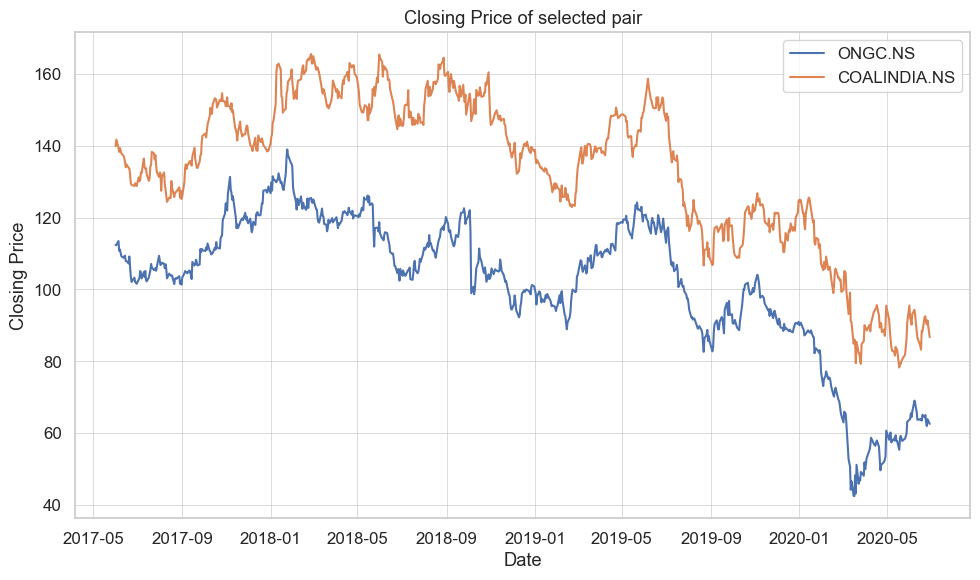

In [41]:
sns.lineplot(stock_prices[coint_pairs.iloc[0, 0]], label=coint_pairs.iloc[0, 0])
sns.lineplot(stock_prices[coint_pairs.iloc[0, 1]], label=coint_pairs.iloc[0, 1])
plt.title('Closing Price of selected pair')
plt.ylabel('Closing Price')
plt.xlabel('Date')
sns.set_style('whitegrid')
plt.tight_layout()
plt.show()

In [42]:
stock1 = coint_pairs.iloc[0, 1]
stock2 = coint_pairs.iloc[0, 0]

hedge_ratio = coint_pairs.iloc[0, 4]

In [43]:
startdate = "2020-07-01"
enddate = "2023-07-31"

stockprices = yf.download([stock1, stock2], start=startdate, end=enddate)['Close']

[*********************100%***********************]  2 of 2 completed


In [44]:
stockprices

Ticker,COALINDIA.NS,ONGC.NS
Date,,
2020-07-01,86.038895,61.022709
2020-07-02,85.878197,62.084621
2020-07-03,86.938805,62.501816
2020-07-06,87.324486,63.525818
2020-07-07,85.396080,62.160477
...,...,...
2023-07-24,201.895920,154.956497
2023-07-25,201.021729,156.768860
2023-07-26,201.502533,156.723541


In [45]:

spread = -stockprices[stock1]*hedge_ratio + stockprices[stock2]

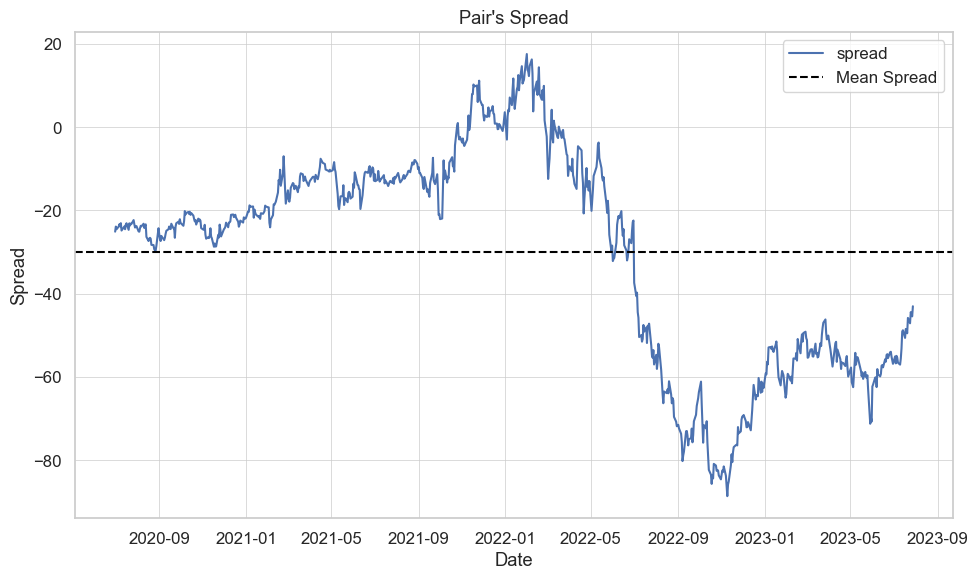

In [46]:
sns.lineplot(spread, label='spread')
plt.axhline(spread.mean(), color='black', linestyle='--', label='Mean Spread')
plt.title("Pair's Spread")
plt.ylabel('Spread')
plt.xlabel('Date')
sns.set_style('whitegrid')
plt.legend()
plt.tight_layout()
plt.show()


In [47]:

def zscore(series):
    lookback = 21
    scores = []
    for i in range(lookback, len(series)):
      window = series[i-lookback:i]
      scores.append((series[i]-window.mean())/window.std())
    return pd.Series(scores, index = series.index[lookback:])

In [48]:

zscore = zscore(spread)

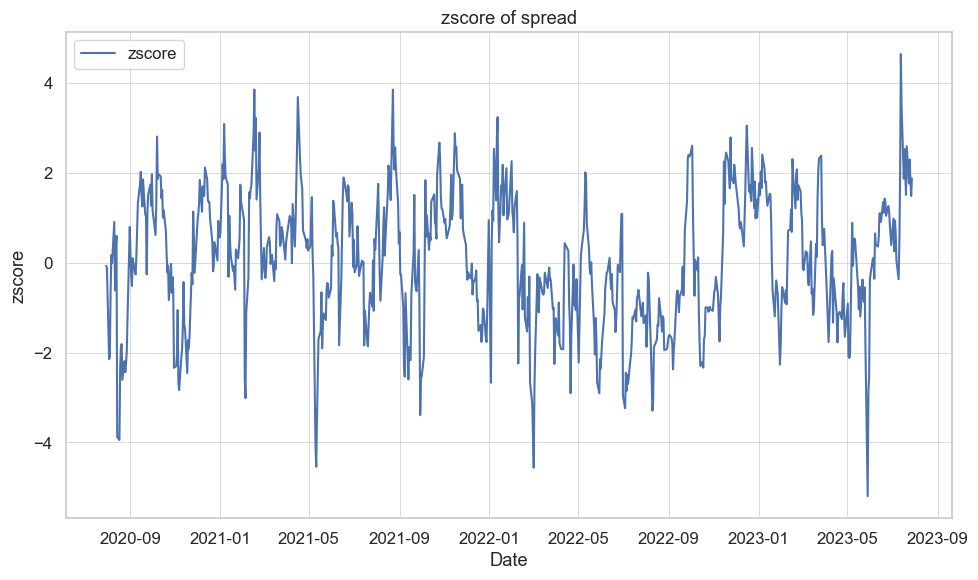

In [49]:

sns.lineplot(zscore, label = 'zscore')
plt.title("zscore of spread")
plt.ylabel('zscore')
plt.xlabel('Date')
sns.set_style('whitegrid')
plt.tight_layout()
plt.show()

In [50]:
# Create a dataframe for trading signals
signals = pd.DataFrame()
signals[stock1] = stockprices[stock1]
signals[stock2] = stockprices[stock2]
signals['spread'] = spread
signals['zscore'] = zscore

signals.dropna(inplace = True)

signals['signal1'] = np.select([signals['zscore'] > 1, signals['zscore'] < -1], [1, -1], default = 0)
signals['position1'] = 0

signals['position1'] = signals['signal1'].diff()
if signals['signal1'][0] != 0:
    signals['position1'][0] = signals['signal1'][0]   
signals['signal2'] = -signals['signal1']
signals['position2'] = -signals['position1']

signals.dropna(inplace = True)
signals# Create a dataframe for trading signals
signals = pd.DataFrame()
signals[stock1] = stockprices[stock1]
signals[stock2] = stockprices[stock2]
signals['spread'] = spread
signals['zscore'] = zscore

signals.dropna(inplace = True)

signals['signal1'] = np.select([signals['zscore'] > 1, signals['zscore'] < -1], [1, -1], default = 0)
signals['position1'] = 0

signals['position1'] = signals['signal1'].diff()
if signals['signal1'][0] != 0:
    signals['position1'][0] = signals['signal1'][0]   
signals['signal2'] = -signals['signal1']
signals['position2'] = -signals['position1']

signals.dropna(inplace = True)
signals

,COALINDIA.NS,ONGC.NS,spread,zscore,signal1,position1,signal2,position2
Date,,,,,,,,
2020-07-31,83.082001,59.391903,-23.763881,-0.114102,0,0.0,0,-0.0
2020-08-03,82.535614,57.571457,-25.037455,-2.148657,-1,-1.0,1,1.0
2020-08-04,82.760605,57.723152,-25.110951,-2.082439,-1,0.0,1,-0.0
2020-08-05,82.567764,58.367889,-24.273201,-0.681136,0,1.0,0,-1.0
2020-08-06,82.824875,59.202259,-23.696171,0.163142,0,0.0,0,-0.0
...,...,...,...,...,...,...,...,...
2023-07-24,201.895920,154.956497,-47.118722,1.763159,1,0.0,-1,-0.0
2023-07-25,201.021729,156.768860,-44.431392,2.296226,1,0.0,-1,-0.0
2023-07-26,201.502533,156.723541,-44.957942,1.821206,1,0.0,-1,-0.0


In [51]:
# Create a dataframe for trading signals
signals = pd.DataFrame()
signals[stock1] = stockprices[stock1]
signals[stock2] = stockprices[stock2]
signals['spread'] = spread
signals['zscore'] = zscore

signals.dropna(inplace = True)

signals['signal1'] = np.select([signals['zscore'] > 1, signals['zscore'] < -1], [1, -1], default = 0)
signals['position1'] = 0

signals['position1'] = signals['signal1'].diff()
if signals['signal1'][0] != 0:
    signals['position1'][0] = signals['signal1'][0]   
signals['signal2'] = -signals['signal1']
signals['position2'] = -signals['position1']

signals.dropna(inplace = True)
signals

,COALINDIA.NS,ONGC.NS,spread,zscore,signal1,position1,signal2,position2
Date,,,,,,,,
2020-07-31,83.082001,59.391903,-23.763881,-0.114102,0,0.0,0,-0.0
2020-08-03,82.535614,57.571457,-25.037455,-2.148657,-1,-1.0,1,1.0
2020-08-04,82.760605,57.723152,-25.110951,-2.082439,-1,0.0,1,-0.0
2020-08-05,82.567764,58.367889,-24.273201,-0.681136,0,1.0,0,-1.0
2020-08-06,82.824875,59.202259,-23.696171,0.163142,0,0.0,0,-0.0
...,...,...,...,...,...,...,...,...
2023-07-24,201.895920,154.956497,-47.118722,1.763159,1,0.0,-1,-0.0
2023-07-25,201.021729,156.768860,-44.431392,2.296226,1,0.0,-1,-0.0
2023-07-26,201.502533,156.723541,-44.957942,1.821206,1,0.0,-1,-0.0


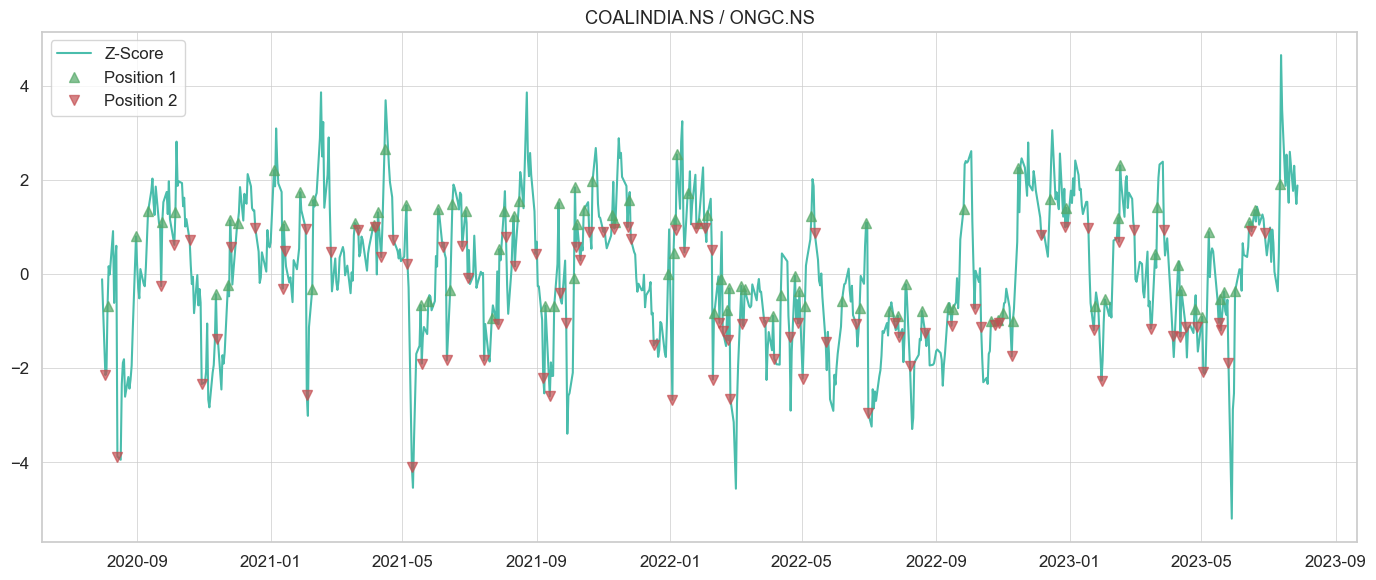

In [52]:

fig = plt.figure(figsize=(14, 6))
bx = fig.add_subplot(111)
series = bx.plot(signals['zscore'], c='#4abdac')
a = (signals['position1'] == 1) | (signals['position1'] == 2)
b = (signals['position1'] == -1) | (signals['position1'] == -2)
long = bx.plot(signals['zscore'][a], lw = 0, marker = '^', markersize = 7, c = 'g', alpha = 0.7)
short = bx.plot(signals['zscore'][b], lw = 0, marker = 'v', markersize = 7, c = 'r', alpha = 0.7)
plt.title(f'{stock1} / {stock2}')
plt.legend(['Z-Score', 'Position 1', 'Position 2'])
sns.set_style('whitegrid')
plt.tight_layout()
plt.show()

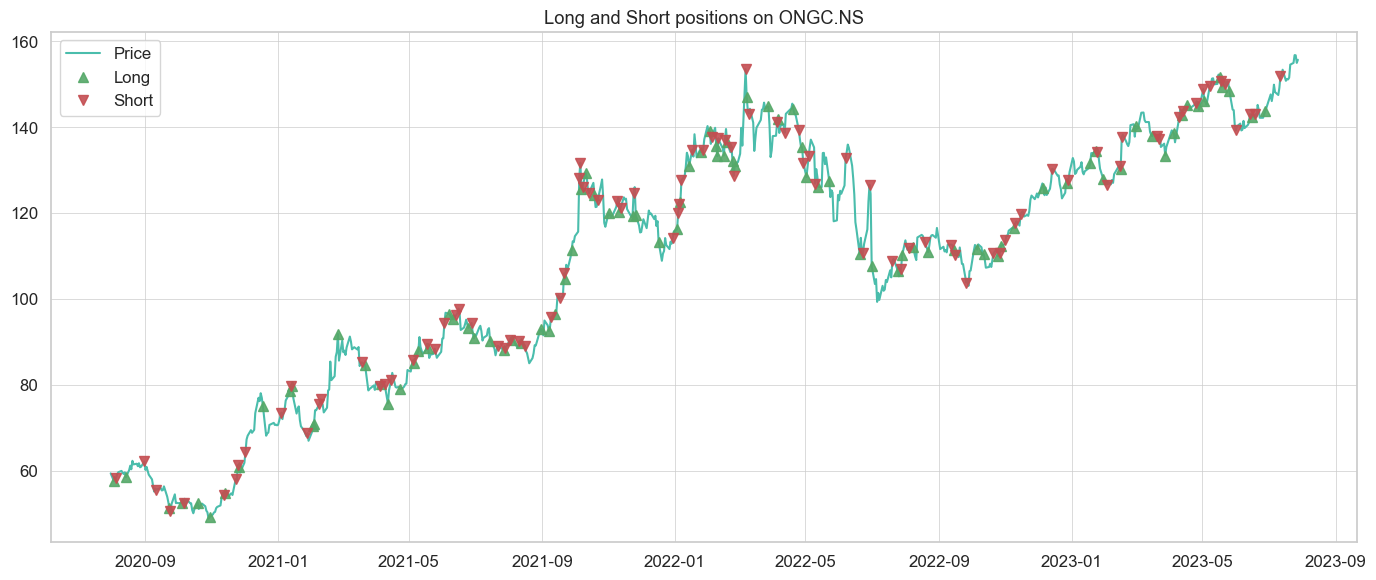

In [55]:

fig = plt.figure(figsize=(14,6))
bx = fig.add_subplot(111)
l1 = bx.plot(signals[stock2], c='#4abdac')
u1 = bx.plot(signals[stock2][b], lw=0, marker='^', markersize=7, c='g',alpha=0.9)
u2, = bx.plot(signals[stock2][a], lw=0, marker='v', markersize=7, c='r',alpha=0.9)
plt.title('Long and Short positions on '+ str(stock2))
plt.legend(['Price', 'Long', 'Short'])
sns.set_style('whitegrid')
plt.tight_layout()
plt.show()

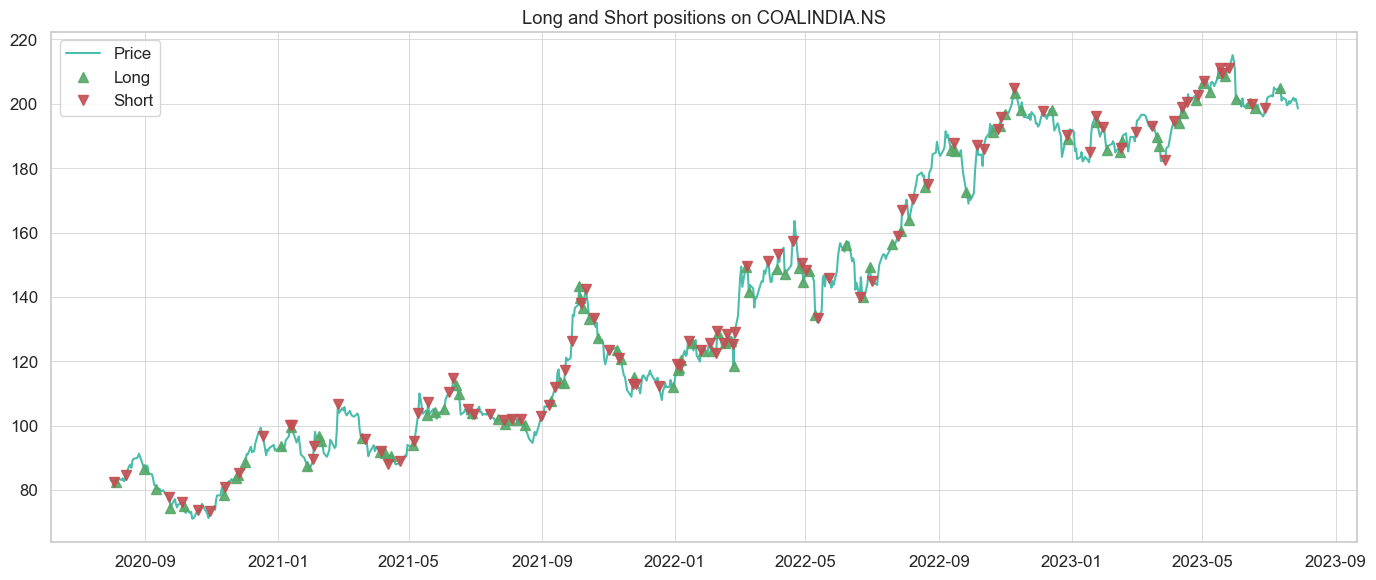

In [56]:

fig = plt.figure(figsize=(14,6))
bx = fig.add_subplot(111)
l1 = bx.plot(signals[stock1], c='#4abdac')
u1 = bx.plot(signals[stock1][a], lw=0, marker='^', markersize=7, c='g',alpha=0.9)
u2, = bx.plot(signals[stock1][b], lw=0, marker='v', markersize=7, c='r',alpha=0.9)
plt.title('Long and Short positions on '+ str(stock1))
plt.legend(['Price', 'Long', 'Short'])
sns.set_style('whitegrid')
plt.tight_layout()
plt.show()

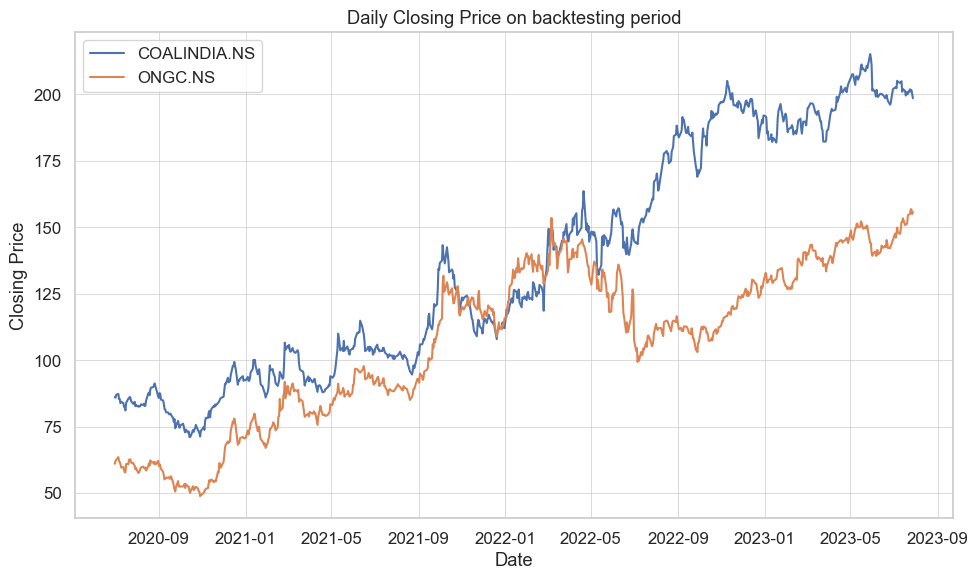

In [27]:
sns.lineplot(stockprices[stock1], label=stock1)
sns.lineplot(stockprices[stock2], label=stock2)
plt.title('Daily Closing Price on backtesting period')
plt.ylabel('Closing Price')
plt.xlabel('Date')
sns.set_style('whitegrid')
plt.tight_layout()
plt.show()

In [28]:
initial_capital = 100000

w1 = 0.5
w2 = 1 - w1

# Shares to buy for each stock
shares1 = (w1*initial_capital)// (signals[stock1][0])
shares2 = (w2*initial_capital)// (signals[stock2][0])

#PnL for stock 1
portfolio = pd.DataFrame()
portfolio['holdings1'] = signals['position1'].cumsum() * signals[stock1] * shares1
portfolio['cash1'] = w1*initial_capital - (signals['position1'] * signals[stock1] * shares1).cumsum()
portfolio['total1'] = portfolio['holdings1'] + portfolio['cash1']
portfolio['return1'] = portfolio['total1'].pct_change()

# PnL for stock 2
portfolio['holdings2'] = signals['position2'].cumsum() * signals[stock2] * shares2
portfolio['cash2'] = w2*initial_capital - (signals['position2'] * signals[stock2] * shares2).cumsum()
portfolio['total2'] = portfolio['holdings2'] + portfolio['cash2']
portfolio['return2'] = portfolio['total2'].pct_change()

# Total PnL
portfolio['total'] = portfolio['total1'] + portfolio['total2']
portfolio = portfolio.dropna()

In [29]:
portfolio

,holdings1,cash1,total1,return1,holdings2,cash2,total2,return2,total
Date,,,,,,,,,
2020-08-03,-49603.904022,99603.904022,50000.000000,0.000000,48417.588844,1582.411156,50000.000000,0.000000,100000.000000
2020-08-04,-49739.123520,99603.904022,49864.780502,-0.002704,48545.183800,1582.411156,50127.594955,0.002552,99992.375458
2020-08-05,0.000000,49980.682274,49980.682274,0.002324,0.000000,50669.809353,50669.809353,0.010817,100650.491627
2020-08-06,0.000000,49980.682274,49980.682274,0.000000,0.000000,50669.809353,50669.809353,0.000000,100650.491627
2020-08-07,0.000000,49980.682274,49980.682274,0.000000,0.000000,50669.809353,50669.809353,0.000000,100650.491627
...,...,...,...,...,...,...,...,...,...
2023-07-24,121339.447800,-66918.049927,54421.397873,0.019187,-130318.414139,240633.164261,110314.750122,-0.003099,164736.147995
2023-07-25,120814.058838,-66918.049927,53896.008911,-0.009654,-131842.611145,240633.164261,108790.553116,-0.013817,162686.562027
2023-07-26,121103.022308,-66918.049927,54184.972382,0.005362,-131804.485367,240633.164261,108828.678894,0.000350,163013.651276


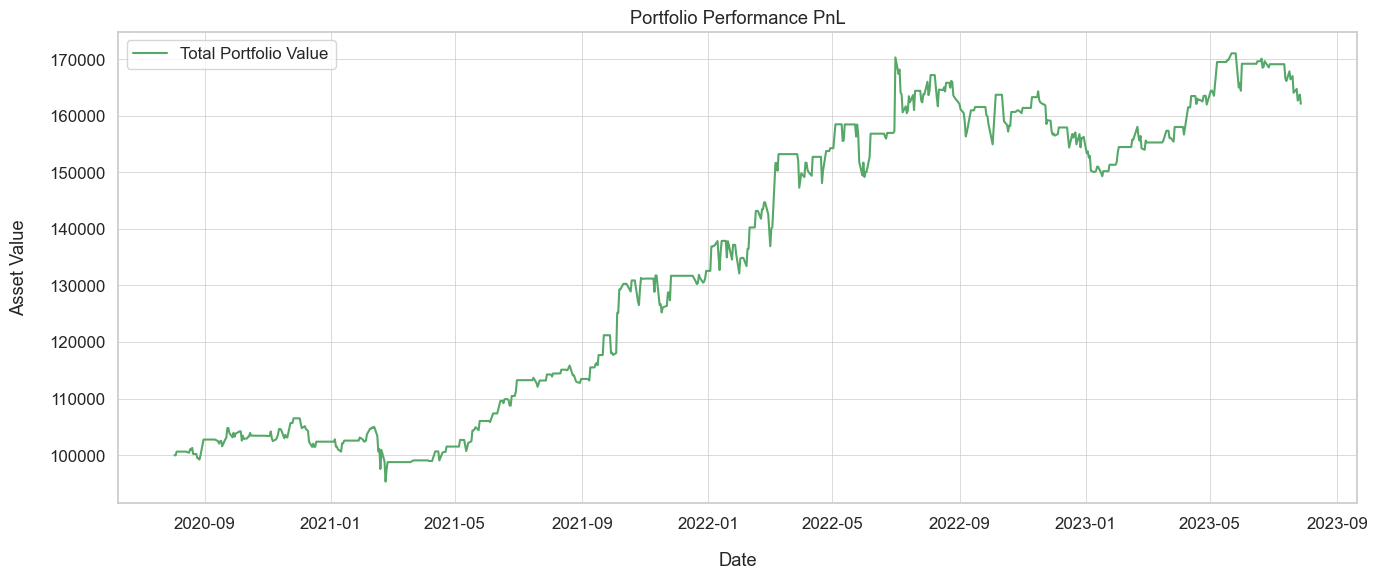

In [57]:

fig = plt.figure(figsize=(14,6),)
ax = fig.add_subplot(111)
l1, = ax.plot(portfolio['total'], c='g')
ax.set_ylabel('Asset Value')
ax.yaxis.labelpad=15
ax.set_xlabel('Date')
ax.xaxis.labelpad=15
plt.title('Portfolio Performance PnL')
plt.legend(['Total Portfolio Value'])
sns.set_style('whitegrid')
plt.tight_layout()
plt.show()

In [58]:
final_portfolio = portfolio['total'].iloc[-1]
initial_portfolio = portfolio['total'].iloc[0]
delta = len(portfolio.index)
print('Number of trading days = ', delta)
YEAR_DAYS = 252
returns = (final_portfolio/initial_portfolio) ** (YEAR_DAYS/delta) - 1
print('CAGR = {:.3f}%' .format(returns * 100))

Number of trading days =  744
CAGR = 17.777%


In [59]:
cummulative_return = (final_portfolio/initial_portfolio)-1
print('Cummulative Return = {:.3f}%' .format(cummulative_return * 100))

Cummulative Return = 62.104%


In [60]:
drawdown = qs.stats.max_drawdown(portfolio['total'])
print("Maximmum Drawdown of trading strategy:", np.round(drawdown*100, 3), "%")

Maximmum Drawdown of trading strategy: -12.322 %


In [61]:
sharpe_ratio = qs.stats.sharpe(portfolio['total'])
print("Sharpe Ratio:", np.round(sharpe_ratio, 3))

Sharpe Ratio: 1.076


In [62]:
print('Frequency of trades:', np.round(abs(signals['position1']).sum()/len(portfolio)*252, 3), 'per year')

Frequency of trades: 63.339 per year
